<a href="https://colab.research.google.com/github/bautistacoyotecatl1-svg/Modulo-2-Modelos-Estadisticos/blob/main/02_Variables_aleatorias_y_distribuciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portada: Variables aleatorias y distribuciones

## Del modelo probabilístico a la simulación

**Bautista Coyotecatl Gerardo**

Este cuaderno desarrolla la secuencia conceptual

$$
(\Omega,\mathcal F,P)\longrightarrow X\longrightarrow P_X
\longrightarrow \text{características y distribuciones}
\longrightarrow \text{simulación}\longrightarrow \text{LGN, TCL y Monte Carlo}.
$$

## Tabla de contenidos

1. [Introducción y objetivos](#1.-Introducción-y-objetivos)
2. [De espacio muestral a variable aleatoria](#2.-De-espacio-muestral-a-variable-aleatoria)
3. [Ley de probabilidad: soporte, PMF, PDF y CDF](#3.-Ley-de-probabilidad:-soporte,-PMF,-PDF-y-CDF)
4. [Características numéricas y transformadas](#4.-Características-numéricas-y-transformadas)
5. [Distribuciones discretas](#5.-Distribuciones-discretas)
6. [Distribuciones continuas](#6.-Distribuciones-continuas)
7. [Comparación de distribuciones y validación por simulación](#7.-Comparación-de-distribuciones-y-validación-por-simulación)
8. [Números pseudoaleatorios y generación](#8.-Números-pseudoaleatorios-y-generación)
9. [Ley de los Grandes Números](#9.-Ley-de-los-Grandes-Números)
10. [Teorema Central del Límite](#10.-Teorema-Central-del-Límite)
11. [Aproximación normal a la binomial](#11.-Aproximación-normal-a-la-binomial)
12. [Simulación de Monte Carlo](#12.-Simulación-de-Monte-Carlo)
13. [Laboratorio integrador](#13.-Laboratorio-integrador)
14. [Conclusiones](#14.-Conclusiones)
15. [Bibliografía](#15.-Bibliografía)

## 1. Introducción y objetivos

Una variable aleatoria traduce resultados de un experimento a números. Su **ley de
probabilidad** determina qué valores puede tomar y con qué probabilidad. A partir de
ella se calculan medidas como esperanza y varianza, se selecciona una distribución
adecuada y se construyen simulaciones reproducibles.

### Objetivo general

Relacionar la formulación matemática de las variables aleatorias y sus distribuciones
con su generación computacional, verificando resultados teóricos mediante simulación.

### Objetivos específicos

- Distinguir variables discretas y continuas mediante su soporte y su ley.
- Interpretar PMF, PDF, CDF, esperanza, varianza, momentos y transformadas.
- Reconocer, parametrizar y aplicar distribuciones discretas y continuas usuales.
- Verificar normalización, momentos y probabilidades con SciPy.
- Comprender la LGN, el TCL, la aproximación normal y Monte Carlo por experimentos.

In [ ]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 5)
SEED = 123
rng = np.random.default_rng(SEED)
inicio_ejecucion = time.perf_counter()

## 2. De espacio muestral a variable aleatoria

Sea $(\Omega,\mathcal F,P)$ un espacio de probabilidad. Una **variable aleatoria real**
es una función medible

$$X:\Omega\rightarrow\mathbb R.$$

No agrega azar: asigna un número a cada resultado $\omega$. La probabilidad inducida
por $X$, llamada **ley** o distribución de $X$, es

$$P_X(B)=P(X\in B)=P\bigl(X^{-1}(B)\bigr),\qquad B\subseteq\mathbb R.$$

**Ejemplo.** Al lanzar dos dados, $\Omega=\{1,\ldots,6\}^2$ y
$X(i,j)=i+j$. Muchos resultados elementales se agrupan bajo una misma suma.

In [ ]:
omega = [(i, j) for i in range(1, 7) for j in range(1, 7)]
sumas = np.array([i + j for i, j in omega])
tabla_sumas = (
    pd.Series(sumas, name="suma").value_counts().sort_index()
    .rename("casos").to_frame()
)
tabla_sumas["P(X=x)"] = tabla_sumas["casos"] / len(omega)
tabla_sumas.index.name = "x"
tabla_sumas

,casos,P(X=x)
x,,
2,1,0.02778
3,2,0.05556
4,3,0.08333
5,4,0.11111
6,5,0.13889
7,6,0.16667
8,5,0.13889
9,4,0.11111
10,3,0.08333


La suma es discreta: su soporte es finito, aunque el espacio muestral tenga 36
resultados. Los valores centrales reciben más preimágenes y, por tanto, más masa.

### Variables discretas y continuas

- **Discreta:** su soporte es finito o numerable y asigna masas $P(X=x)$.
- **Absolutamente continua:** su probabilidad se obtiene integrando una densidad;
  para cada punto aislado, $P(X=x)=0$.

Una densidad puede ser mayor que 1 en algún punto; lo que debe estar entre 0 y 1 es
el **área** que representa una probabilidad.

## 3. Ley de probabilidad: soporte, PMF, PDF y CDF

El **soporte** reúne los valores posibles con masa positiva (caso discreto) o la
región donde actúa la densidad (caso continuo).

| Objeto | Definición | Propiedades esenciales |
|---|---|---|
| PMF | $p_X(x)=P(X=x)$ | $p_X(x)\ge0$ y $\sum_xp_X(x)=1$ |
| PDF | $f_X(x)$ y $P(a<X\le b)=\int_a^b f_X(t)\,dt$ | $f_X(x)\ge0$ y $\int_{-\infty}^{\infty}f_X=1$ |
| Función de distribución acumulada (CDF) | $F_X(x)=P(X\le x)$ | no decreciente, continua por la derecha, límites 0 y 1 |

La CDF existe para toda variable aleatoria. En el caso discreto es escalonada; si la
ley es absolutamente continua, $F_X(x)=\int_{-\infty}^x f_X(t)\,dt$ y
$F'_X(x)=f_X(x)$ donde la derivada existe.

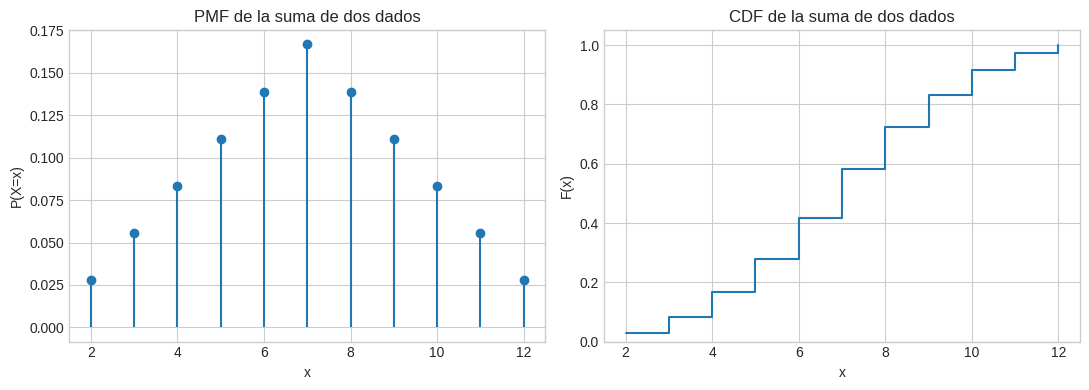

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
x_d = tabla_sumas.index.to_numpy()
p_d = tabla_sumas["P(X=x)"].to_numpy()
ax[0].stem(x_d, p_d, basefmt=" ")
ax[0].set(title="PMF de la suma de dos dados", xlabel="x", ylabel="P(X=x)")
ax[1].step(x_d, np.cumsum(p_d), where="post")
ax[1].set(title="CDF de la suma de dos dados", xlabel="x", ylabel="F(x)", ylim=(0, 1.05))
plt.tight_layout()
plt.show()

## 4. Características numéricas y transformadas

La **esperanza** es el promedio ponderado de la ley:

$$E[X]=\sum_x x\,p_X(x)\quad\text{o}\quad E[X]=\int_{-\infty}^{\infty}x f_X(x)\,dx.$$

Para una función $g$, $E[g(X)]$ se obtiene sustituyendo $x$ por $g(x)$ en la suma o
integral. La **varianza** y la desviación estándar son

$$\operatorname{Var}(X)=E[(X-\mu)^2]=E[X^2]-\mu^2,\qquad
\sigma=\sqrt{\operatorname{Var}(X)}.$$

El momento de orden $r$ respecto del origen es $\mu'_r=E[X^r]$; el momento central
es $\mu_r=E[(X-\mu)^r]$. Así, $\mu'_1=\mu$ y $\mu_2=\sigma^2$.

La **función generadora de momentos** (cuando es finita alrededor de cero) y la
**función característica** son

$$M_X(t)=E[e^{tX}],\qquad \varphi_X(t)=E[e^{itX}].$$

Si la MGF existe cerca de $0$, $M_X^{(r)}(0)=E[X^r]$. La función característica
siempre existe porque $|e^{itX}|=1$ y también determina de manera única la ley.

In [ ]:
# Comprobación exacta para la suma de dos dados
mu_suma = np.sum(x_d * p_d)
var_suma = np.sum((x_d - mu_suma)**2 * p_d)
momentos = pd.DataFrame({
    "cantidad": ["E[X]", "E[X²]", "Var(X)", "DE(X)"],
    "valor": [mu_suma, np.sum(x_d**2*p_d), var_suma, np.sqrt(var_suma)]
})
momentos

,cantidad,valor
0,E[X],7.00000
1,E[X²],54.83333
2,Var(X),5.83333
3,DE(X),2.41523


El valor esperado de la suma es 7 y su varianza es $35/6$. La esperanza no tiene
que ser un resultado frecuente ni siquiera pertenecer al soporte; resume el centro
de la distribución a largo plazo.

In [ ]:
# Ejemplo de MGF: Bernoulli(p), M(t)=1-p+p exp(t)
p = 0.35
t0 = 0.0
h = 1e-5
M = lambda t: 1 - p + p*np.exp(t)
M1 = (M(t0+h)-M(t0-h))/(2*h)
M2 = (M(t0+h)-2*M(t0)+M(t0-h))/h**2
pd.DataFrame({
    "comprobación": ["M(0)=1", "M'(0)=E[X]", "M''(0)=E[X²]"],
    "numérica": [M(0), M1, M2],
    "teórica": [1, p, p]
})

,comprobación,numérica,teórica
0,M(0)=1,1.00,1.00
1,M'(0)=E[X],0.35,0.35
2,M''(0)=E[X²],0.35,0.35


## 5. Distribuciones discretas

La parametrización siguiente se usará en todo el cuaderno.

| Distribución | Soporte | PMF | $E[X]$ | $Var(X)$ | Interpretación y condiciones |
|---|---:|---|---:|---:|---|
| Uniforme discreta | $a,\ldots,b$ | $1/(b-a+1)$ | $(a+b)/2$ | $((b-a+1)^2-1)/12$ | enteros equiprobables |
| Bernoulli$(p)$ | $0,1$ | $p^x(1-p)^{1-x}$ | $p$ | $p(1-p)$ | un ensayo, éxito con probabilidad $p$ |
| Binomial$(n,p)$ | $0,\ldots,n$ | ${n\choose x}p^x(1-p)^{n-x}$ | $np$ | $np(1-p)$ | suma de $n$ Bernoulli independientes con $p$ constante |
| Poisson$(\lambda)$ | $0,1,\ldots$ | $e^{-\lambda}\lambda^x/x!$ | $\lambda$ | $\lambda$ | conteo en una región con tasa media $\lambda$ |
| Geométrica$(p)$ | $1,2,\ldots$ | $(1-p)^{x-1}p$ | $1/p$ | $(1-p)/p^2$ | ensayo del primer éxito; convención inicia en 1 |
| Binomial negativa$(r,p)$ | $r,r+1,\ldots$ | ${x-1\choose r-1}p^r(1-p)^{x-r}$ | $r/p$ | $r(1-p)/p^2$ | ensayo del $r$-ésimo éxito |
| Hipergeométrica$(N,K,n)$ | $\max(0,n-N+K),\ldots,\min(n,K)$ | $\frac{{K\choose x}{N-K\choose n-x}}{{N\choose n}}$ | $nK/N$ | $n\frac KN(1-\frac KN)\frac{N-n}{N-1}$ | éxitos en $n$ extracciones **sin reemplazo** |

La CDF discreta es $F(x)=\sum_{k\le x}p(k)$. Bernoulli modela un indicador;
binomial, éxitos con reemplazo/independencia; hipergeométrica, muestreo finito sin
reemplazo; Poisson, conteos; geométrica y binomial negativa, tiempos de espera en
número de ensayos.

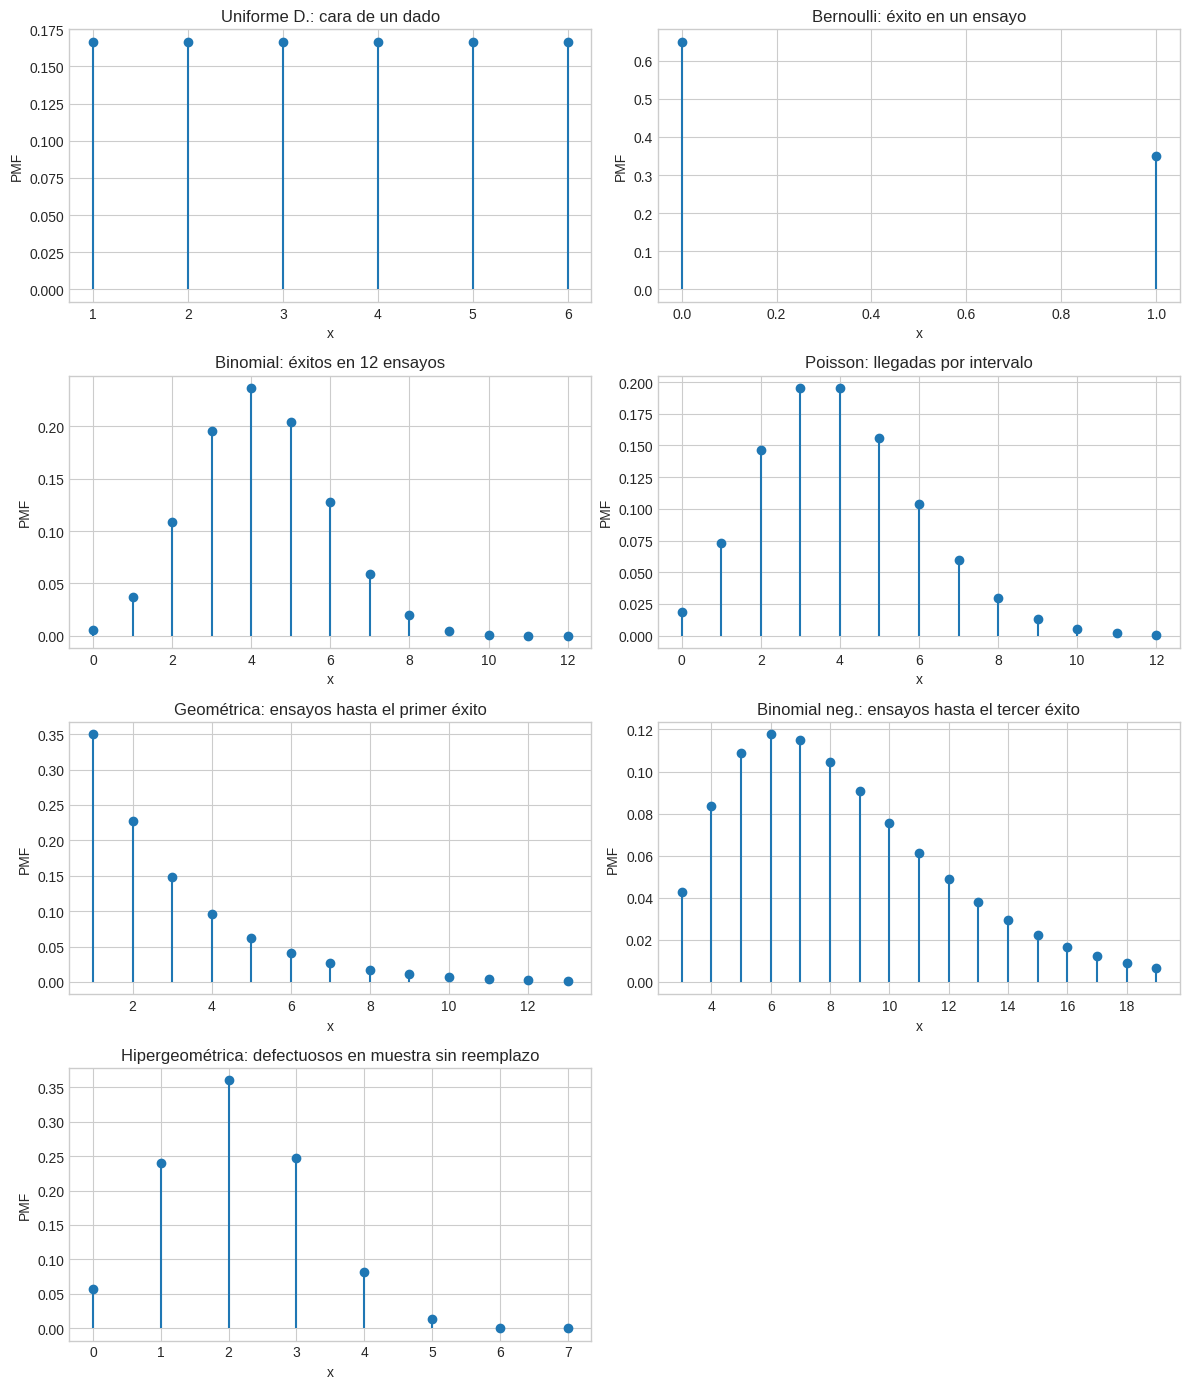

In [ ]:
discretas = {
    "Uniforme D.": (stats.randint(1, 7), np.arange(1, 7), "cara de un dado"),
    "Bernoulli": (stats.bernoulli(0.35), np.arange(0, 2), "éxito en un ensayo"),
    "Binomial": (stats.binom(12, 0.35), np.arange(0, 13), "éxitos en 12 ensayos"),
    "Poisson": (stats.poisson(4), np.arange(0, 13), "llegadas por intervalo"),
    "Geométrica": (stats.geom(0.35), np.arange(1, 14), "ensayos hasta el primer éxito"),
    "Binomial neg.": (stats.nbinom(3, 0.35, loc=3), np.arange(3, 20),
                      "ensayos hasta el tercer éxito"),
    "Hipergeométrica": (stats.hypergeom(30, 9, 7), np.arange(0, 8),
                        "defectuosos en muestra sin reemplazo"),
}

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for ax, (nombre, (rv, xs, aplicacion)) in zip(axes.flat, discretas.items()):
    ax.stem(xs, rv.pmf(xs), basefmt=" ")
    ax.set(title=f"{nombre}: {aplicacion}", xlabel="x", ylabel="PMF")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

### Convenciones de SciPy para las discretas

- `randint(low, high)` incluye `low` y excluye `high`.
- `geom(p)` cuenta ensayos hasta el primer éxito: soporte $1,2,\ldots$.
- `nbinom(r,p)` cuenta **fracasos antes del éxito número $r$**. Para representar el
  número total de ensayos se usa `stats.nbinom(r,p,loc=r)`.
- `hypergeom(M, n, N)` usa población total `M`, éxitos poblacionales `n` y tamaño
  de muestra `N`.

Ejemplos: llamadas por hora (Poisson), intentos hasta conectar una llamada
(geométrica), piezas defectuosas en una muestra de un lote (hipergeométrica).

In [ ]:
# Normalización de las PMF (colas infinitas truncadas con masa residual controlada)
filas = []
for nombre, (rv, xs, _) in discretas.items():
    lo = int(rv.ppf(1e-10))
    hi = int(rv.ppf(1-1e-10))
    grid = np.arange(lo, hi+1)
    suma = rv.pmf(grid).sum()
    filas.append([nombre, lo, hi, suma, abs(1-suma)])
check_pmf = pd.DataFrame(filas, columns=["Distribución", "inicio", "fin", "suma PMF", "error"])
assert (check_pmf["error"] < 1e-8).all()
check_pmf

,Distribución,inicio,fin,suma PMF,error
0,Uniforme D.,1,6,1.0,1.11022e-16
1,Bernoulli,0,1,1.0,0.00000e+00
2,Binomial,0,12,1.0,0.00000e+00
3,Poisson,0,22,1.0,5.97338e-11
4,Geométrica,1,54,1.0,7.89444e-11
5,Binomial neg.,3,69,1.0,8.85851e-11
6,Hipergeométrica,0,7,1.0,2.22045e-16


Las sumas son 1 salvo error numérico y truncamiento de colas. Esto comprueba que
las funciones utilizadas son PMF válidas con las parametrizaciones declaradas.

## 6. Distribuciones continuas

| Distribución | Soporte | PDF | $E[X]$ | $Var(X)$ | Interpretación y condiciones |
|---|---:|---|---:|---:|---|
| Uniforme continua$(a,b)$ | $a<x<b$ | $1/(b-a)$ | $(a+b)/2$ | $(b-a)^2/12$ | todos los intervalos de igual longitud son equiprobables |
| Exponencial$(\\lambda)$ | $x\\ge0$ | $\\lambda e^{-\\lambda x}$ | $1/\\lambda$ | $1/\\lambda^2$ | tiempo entre eventos; tasa $\\lambda>0$; sin memoria |
| Normal$(\\mu,\\sigma^2)$ | $\\mathbb R$ | $\\frac1{\\sigma\\sqrt{2\\pi}}e^{-(x-\\mu)^2/(2\\sigma^2)}$ | $\\mu$ | $\\sigma^2$ | errores y sumas de muchos efectos; $\\sigma>0$ |
| Gamma$(\\alpha,\\theta)$ | $x>0$ | $\\frac{x^{\\alpha-1}e^{-x/\\theta}}{\\Gamma(\\alpha)\\theta^\\alpha}$ | $\\alpha\\theta$ | $\\alpha\\theta^2$ | espera hasta acumulación de eventos; forma $\\alpha>0$, escala $\\theta>0$ |

CDF útiles: uniforme $F(x)=(x-a)/(b-a)$ en $[a,b]$; exponencial
$F(x)=1-e^{-\\lambda x}$; normal
$F(x)=\Phi((x-\mu)/\sigma)$; gamma se evalúa mediante la gamma incompleta.

**SciPy usa `loc` y `scale`:** uniforme `loc=a, scale=b-a`; exponencial
`scale=1/λ`; normal `loc=μ, scale=σ`; gamma `a=α, scale=θ`. En gamma se adopta
la parametrización forma–escala, no forma–tasa.

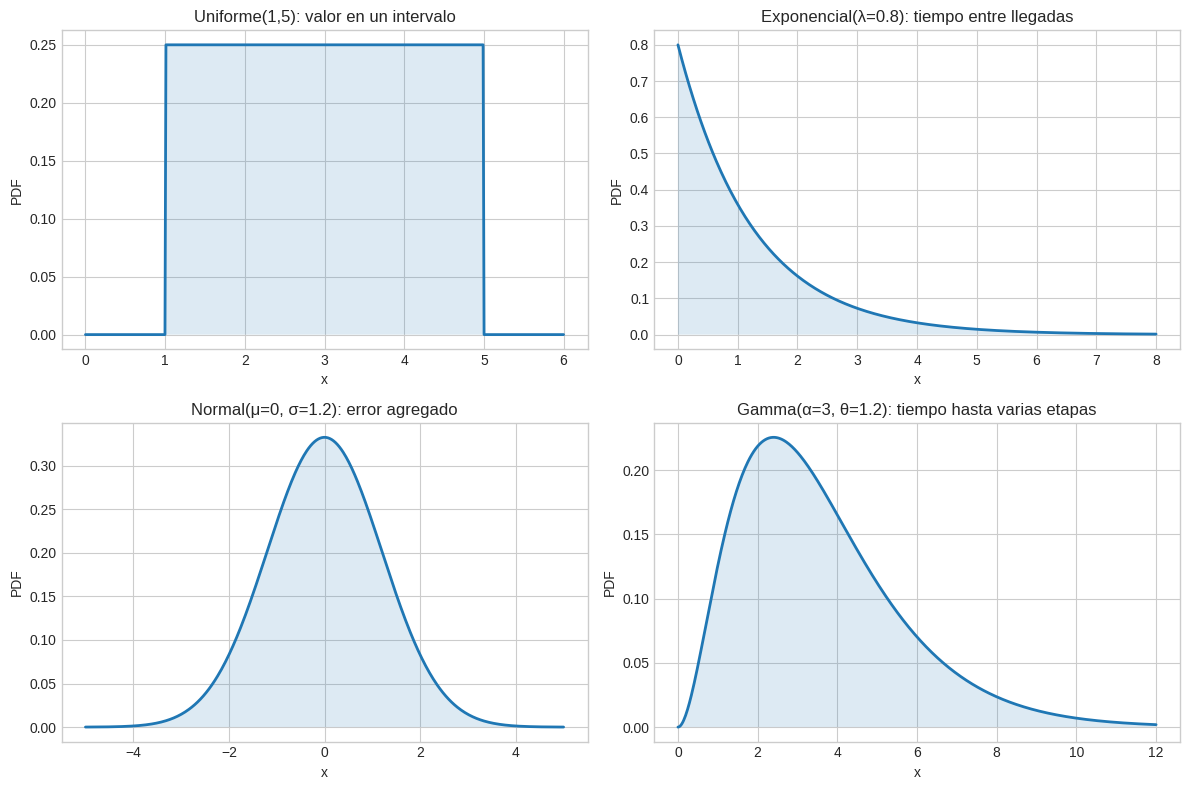

In [ ]:
continuas = {
    "Uniforme(1,5)": (stats.uniform(loc=1, scale=4), np.linspace(0, 6, 500),
                      "valor en un intervalo"),
    "Exponencial(λ=0.8)": (stats.expon(scale=1/0.8), np.linspace(0, 8, 500),
                            "tiempo entre llegadas"),
    "Normal(μ=0, σ=1.2)": (stats.norm(loc=0, scale=1.2), np.linspace(-5, 5, 500),
                             "error agregado"),
    "Gamma(α=3, θ=1.2)": (stats.gamma(a=3, scale=1.2), np.linspace(0, 12, 500),
                            "tiempo hasta varias etapas"),
}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (nombre, (rv, xs, aplicacion)) in zip(axes.flat, continuas.items()):
    ax.plot(xs, rv.pdf(xs), lw=2)
    ax.fill_between(xs, rv.pdf(xs), alpha=.15)
    ax.set(title=f"{nombre}: {aplicacion}", xlabel="x", ylabel="PDF")
plt.tight_layout()
plt.show()

In [ ]:
# Comprobación numérica de las PDF por integración en cuantiles extremos
filas = []
for nombre, (rv, _, _) in continuas.items():
    lo, hi = rv.ppf([1e-10, 1-1e-10])
    integral = stats.quad_vec(rv.pdf, lo, hi)[0] if hasattr(stats, "quad_vec") else np.nan
    # scipy.integrate ofrece la cuadratura; aquí usamos expect para evitar otra importación
    integral = rv.expect(lambda x: 1.0, lb=lo, ub=hi)
    filas.append([nombre, lo, hi, integral, abs(1-integral)])
check_pdf = pd.DataFrame(filas, columns=["Distribución", "límite inf.", "límite sup.",
                                         "integral PDF", "masa fuera"])
assert (check_pdf["masa fuera"] < 1e-8).all()
check_pdf

,Distribución,límite inf.,límite sup.,integral PDF,masa fuera
0,"Uniforme(1,5)",1.00000e+00,5.00000,1.0,2.00000e-10
1,Exponencial(λ=0.8),1.25000e-10,28.78231,1.0,2.00000e-10
2,"Normal(μ=0, σ=1.2)",-7.63361e+00,7.63361,1.0,2.00000e-10
3,"Gamma(α=3, θ=1.2)",1.01233e-03,34.97508,1.0,2.00000e-10


Las integrales capturan prácticamente toda la masa. La pequeña diferencia respecto
de 1 corresponde a las colas excluidas deliberadamente, no a una falla de
normalización.

## 7. Comparación de distribuciones y validación por simulación

| Pregunta | Distribución natural | Distinción clave |
|---|---|---|
| ¿Ocurrió el evento? | Bernoulli | un indicador |
| ¿Cuántos éxitos en $n$ intentos independientes? | Binomial | $n$ fijo |
| ¿Cuántos eventos en una región? | Poisson | tasa media |
| ¿Cuántos ensayos hasta el primer/$r$-ésimo éxito? | Geométrica/binomial negativa | horizonte aleatorio |
| ¿Cuántos éxitos al muestrear un lote? | Hipergeométrica | sin reemplazo |
| ¿Dónde cae un valor sin preferencia dentro de un intervalo? | Uniforme | densidad constante |
| ¿Cuánto tiempo hasta el siguiente evento? | Exponencial | sin memoria |
| ¿Resultado de efectos aditivos? | Normal | simetría |
| ¿Tiempo positivo acumulado en etapas? | Gamma | asimetría y suma de esperas |

Una distribución es una representación condicionada por supuestos. Dos variables
con la misma esperanza pueden diferir radicalmente en soporte, varianza y forma.

In [ ]:
def comparar(rv, nombre, n=60_000):
    muestra = rv.rvs(size=n, random_state=rng)
    return {
        "Distribución": nombre,
        "Media teórica": rv.mean(),
        "Media simulada": muestra.mean(),
        "Varianza teórica": rv.var(),
        "Varianza simulada": muestra.var(ddof=0),
    }

comparaciones = []
for nombre, (rv, _, _) in discretas.items():
    comparaciones.append(comparar(rv, nombre))
for nombre, (rv, _, _) in continuas.items():
    comparaciones.append(comparar(rv, nombre))
tabla_comparacion = pd.DataFrame(comparaciones)
tabla_comparacion["Error relativo media"] = (
    (tabla_comparacion["Media simulada"]-tabla_comparacion["Media teórica"]).abs()
    / tabla_comparacion["Media teórica"].abs().replace(0, np.nan)
)
tabla_comparacion

,Distribución,Media teórica,Media simulada,Varianza teórica,Varianza simulada,Error relativo media
0,Uniforme D.,3.50000,3.49295,2.91667,2.91682,2.01429e-03
1,Bernoulli,0.35000,0.34995,0.22750,0.22748,1.42857e-04
2,Binomial,4.20000,4.21287,2.73000,2.75015,3.06349e-03
3,Poisson,4.00000,4.00573,4.00000,3.94013,1.43333e-03
4,Geométrica,2.85714,2.86492,5.30612,5.32720,2.72083e-03
5,Binomial neg.,8.57143,8.58868,15.91837,16.05560,2.01306e-03
6,Hipergeométrica,2.10000,2.10002,1.16586,1.16525,7.93651e-06
7,"Uniforme(1,5)",3.00000,2.99874,1.33333,1.33215,4.19869e-04
8,Exponencial(λ=0.8),1.25000,1.25048,1.56250,1.54429,3.81284e-04
9,"Normal(μ=0, σ=1.2)",0.00000,0.00539,1.44000,1.44438,NaN


Las medias y varianzas empíricas se aproximan a sus valores teóricos. No deben ser
idénticas: cada muestra conserva variabilidad aleatoria. Aumentar el tamaño suele
reducir el error, pero no de forma monótona en cada realización.

## 8. Números pseudoaleatorios y generación

Un generador pseudoaleatorio produce una secuencia determinista que imita propiedades
estadísticas del azar. La **semilla** fija el estado inicial: la misma semilla y el
mismo algoritmo reproducen la misma secuencia. Esto sirve para auditoría; no convierte
las observaciones en independientes en sentido físico ni vuelve criptográfico al
generador.

En este cuaderno se usa una sola instancia `numpy.random.default_rng(123)`.

### Método de la transformada inversa

Si $U\sim U(0,1)$ y $F^{-1}(u)=\inf\{x:F(x)\ge u\}$, entonces
$X=F^{-1}(U)$ tiene CDF $F$. Para una exponencial de tasa $\lambda$:

$$X=-\frac{\log(1-U)}{\lambda}.$$

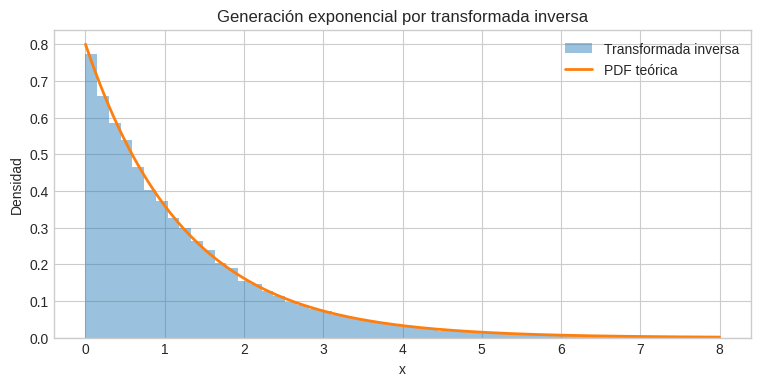

,método,media,varianza
0,Inversa,1.25071,1.55831
1,SciPy,1.24409,1.54774
2,Teoría,1.25000,1.56250


In [ ]:
u = rng.random(50_000)
lam = 0.8
x_inversa = -np.log1p(-u) / lam
x_scipy = stats.expon(scale=1/lam).rvs(size=50_000, random_state=rng)

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 8, 55)
ax.hist(x_inversa, bins=bins, density=True, alpha=.45, label="Transformada inversa")
grid = np.linspace(0, 8, 400)
ax.plot(grid, stats.expon(scale=1/lam).pdf(grid), lw=2, label="PDF teórica")
ax.set(title="Generación exponencial por transformada inversa",
       xlabel="x", ylabel="Densidad")
ax.legend()
plt.show()

pd.DataFrame({
    "método": ["Inversa", "SciPy", "Teoría"],
    "media": [x_inversa.mean(), x_scipy.mean(), 1/lam],
    "varianza": [x_inversa.var(), x_scipy.var(), 1/lam**2]
})

La coincidencia de histograma, media y varianza muestra que la transformación
implementa la ley deseada. Para distribuciones discretas, la inversa generalizada
selecciona el menor valor cuya CDF supera a $U$.

## 9. Ley de los Grandes Números

### Idea intuitiva

Al repetir observaciones independientes con la misma distribución y esperanza
finita, el promedio muestral se estabiliza alrededor de la esperanza.

### Resultado

Para $X_1,X_2,\ldots$ i.i.d. con $E[X_i]=\mu$ (y, para la versión débil usual,
varianza finita),

$$\bar X_n=\frac1n\sum_{i=1}^nX_i\xrightarrow{P}\mu,$$

es decir, para todo $\varepsilon>0$,
$P(|\bar X_n-\mu|>\varepsilon)\to0$. La versión fuerte establece convergencia casi
segura bajo condiciones apropiadas.

Convergencia no significa que una media finita sea exactamente $\mu$, ni que cada
trayectoria se acerque de manera monótona.

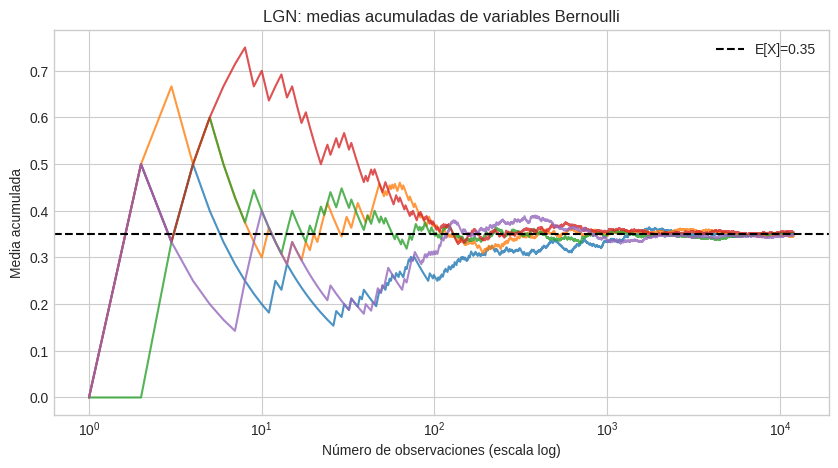

In [ ]:
p_lgn = 0.35
n_lgn = 12_000
trayectorias = 5
fig, ax = plt.subplots(figsize=(10, 5))
for _ in range(trayectorias):
    datos = rng.binomial(1, p_lgn, size=n_lgn)
    medias = np.cumsum(datos) / np.arange(1, n_lgn+1)
    ax.plot(np.arange(1, n_lgn+1), medias, alpha=.8)
ax.axhline(p_lgn, color="black", ls="--", label=f"E[X]={p_lgn}")
ax.set_xscale("log")
ax.set(title="LGN: medias acumuladas de variables Bernoulli",
       xlabel="Número de observaciones (escala log)", ylabel="Media acumulada")
ax.legend()
plt.show()

Las trayectorias fluctúan mucho al inicio y luego se concentran alrededor de
$p=0.35$. La LGN describe esta estabilidad del promedio; no describe la forma de
la distribución del error.

## 10. Teorema Central del Límite

El TCL estudia las **fluctuaciones escaladas** del promedio. Para variables i.i.d.
con media $\mu$ y varianza finita positiva $\sigma^2$,

$$\frac{\sqrt n(\bar X_n-\mu)}{\sigma}\xrightarrow{d}N(0,1).$$

Por ello, para $n$ suficientemente grande,

$$\bar X_n\approx N\left(\mu,\frac{\sigma^2}{n}\right).$$

Partiremos de una población exponencial, claramente asimétrica, y observaremos la
distribución de muchas medias.

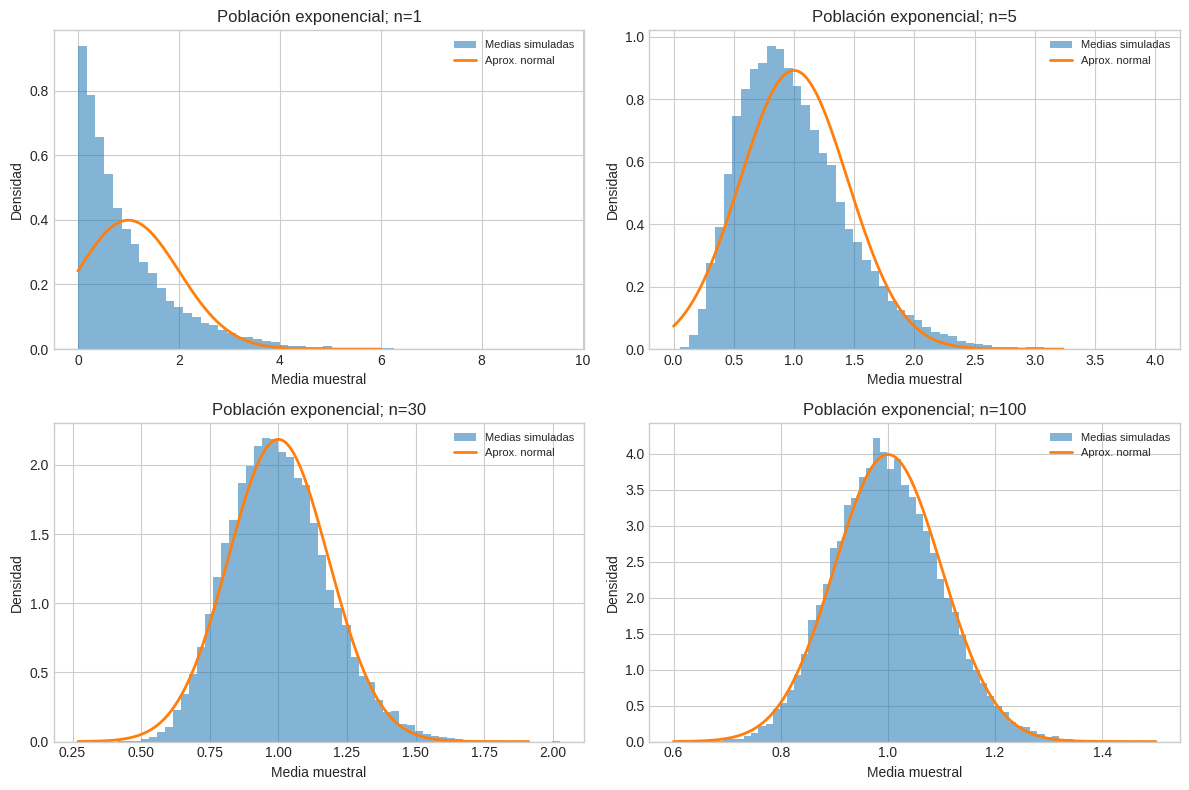

,n,E empírica,Var empírica,Var teórica,Asimetría empírica
0,1,0.99150,0.99153,1.00000,1.98601
1,5,1.00249,0.20267,0.20000,0.89169
2,30,1.00211,0.03312,0.03333,0.36733
3,100,0.99955,0.00998,0.01000,0.20154


In [ ]:
reps = 25_000
ns = [1, 5, 30, 100]
lam_tcl = 1.0
mu, sigma = 1/lam_tcl, 1/lam_tcl
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
resumen_tcl = []

for ax, n in zip(axes.flat, ns):
    medias = rng.exponential(scale=1/lam_tcl, size=(reps, n)).mean(axis=1)
    grid = np.linspace(max(0, mu-4*sigma/np.sqrt(n)), mu+5*sigma/np.sqrt(n), 400)
    ax.hist(medias, bins=55, density=True, alpha=.55, label="Medias simuladas")
    ax.plot(grid, stats.norm(mu, sigma/np.sqrt(n)).pdf(grid), lw=2,
            label="Aprox. normal")
    ax.set(title=f"Población exponencial; n={n}", xlabel="Media muestral", ylabel="Densidad")
    ax.legend(fontsize=8)
    resumen_tcl.append([n, medias.mean(), medias.var(), sigma**2/n,
                        stats.skew(medias)])
plt.tight_layout()
plt.show()

pd.DataFrame(resumen_tcl, columns=["n", "E empírica", "Var empírica",
                                    "Var teórica", "Asimetría empírica"])

Al crecer $n$, el centro permanece cerca de $\mu=1$, la varianza cae como $1/n$ y
la asimetría disminuye. El TCL no afirma que la población se vuelva normal:
aproxima la distribución de la **media estandarizada**.

### LGN frente a TCL

| Aspecto | LGN | TCL |
|---|---|---|
| Pregunta | ¿A dónde va el promedio? | ¿Cómo se distribuye su error? |
| Convergencia | $\bar X_n\\to\\mu$ | $\sqrt n(\\bar X_n-\\mu)/\\sigma\\to N(0,1)$ |
| Resultado principal | consistencia/estabilidad | aproximación de distribución |
| Uso | justificar promedios y Monte Carlo | probabilidades, errores e inferencia |

## 11. Aproximación normal a la binomial

Si $X\sim\operatorname{Bin}(n,p)$ y $np$ y $n(1-p)$ no son pequeños, entonces

$$X\approx N(np,np(1-p)).$$

Como la binomial es discreta y la normal continua, se usa **corrección por
continuidad**. Por ejemplo,

$$P(a\le X\le b)\approx
P\left(a-\tfrac12<Y<b+\tfrac12\right),\quad
Y\sim N(np,np(1-p)).$$

In [ ]:
n, p, a, b = 80, 0.35, 22, 34
mu_b, sd_b = n*p, np.sqrt(n*p*(1-p))
exacta = stats.binom(n, p).cdf(b) - stats.binom(n, p).cdf(a-1)
normal_cc = stats.norm(mu_b, sd_b).cdf(b+.5) - stats.norm(mu_b, sd_b).cdf(a-.5)
normal_sin = stats.norm(mu_b, sd_b).cdf(b) - stats.norm(mu_b, sd_b).cdf(a)

pd.DataFrame({
    "método": ["Binomial exacta", "Normal con corrección", "Normal sin corrección"],
    "P(22≤X≤34)": [exacta, normal_cc, normal_sin],
    "error absoluto": [0, abs(normal_cc-exacta), abs(normal_sin-exacta)]
})

,método,P(22≤X≤34),error absoluto
0,Binomial exacta,0.87313,0.00000
1,Normal con corrección,0.87240,0.00073
2,Normal sin corrección,0.84040,0.03273


La corrección por continuidad alinea los límites de las barras discretas con áreas
continuas y normalmente mejora la aproximación. Si $p$ está muy cerca de 0 o 1 o
los conteos esperados son pequeños, la aproximación puede ser deficiente.

## 12. Simulación de Monte Carlo

Monte Carlo expresa una cantidad como esperanza y la aproxima mediante un promedio:

$$\theta=E[g(X)],\qquad \hat\theta_N=\frac1N\sum_{i=1}^N g(X_i).$$

La LGN justifica $\hat\theta_N\to\theta$; el TCL explica que su error estándar es
aproximadamente $s_g/\sqrt N$. El procedimiento básico es:

1. definir la cantidad objetivo y una ley de muestreo;
2. generar réplicas;
3. evaluar $g$;
4. promediar y cuantificar el error.

Estimaremos $\pi$ con puntos uniformes en $[-1,1]^2$. Si
$I_i=\mathbf1(X_i^2+Y_i^2\le1)$, entonces $E[I_i]=\pi/4$.

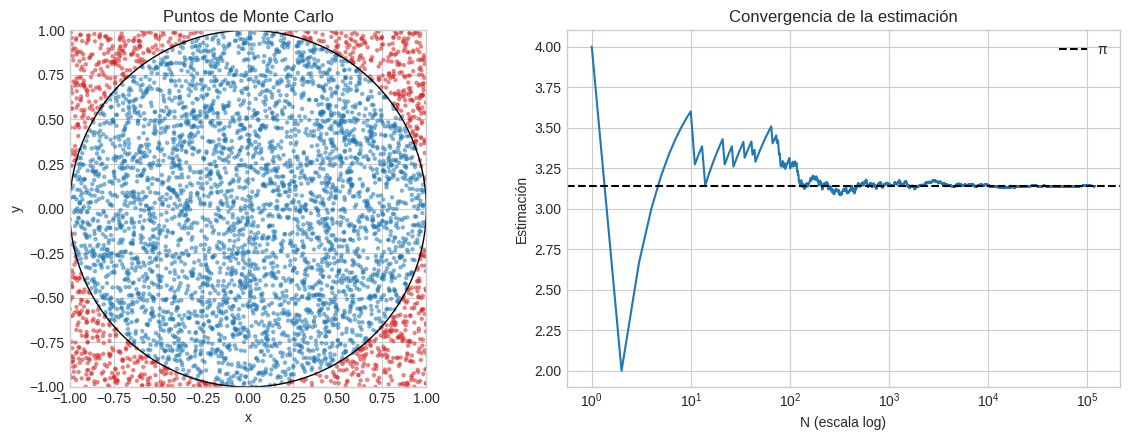

,N,π estimado,π,error absoluto,error estándar aprox.
0,120000,3.1388,3.14159,0.00279,0.00475


In [ ]:
N_mc = 120_000
xy = rng.uniform(-1, 1, size=(N_mc, 2))
dentro = (xy[:, 0]**2 + xy[:, 1]**2 <= 1)
pi_acum = 4*np.cumsum(dentro)/np.arange(1, N_mc+1)
pi_hat = pi_acum[-1]
se_pi = 4*np.sqrt(dentro.mean()*(1-dentro.mean())/N_mc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
m = 5000
axes[0].scatter(xy[:m,0], xy[:m,1], c=np.where(dentro[:m], "tab:blue", "tab:red"),
                s=5, alpha=.45)
circle = plt.Circle((0,0), 1, fill=False, color="black")
axes[0].add_patch(circle)
axes[0].set(title="Puntos de Monte Carlo", xlabel="x", ylabel="y",
            aspect="equal", xlim=(-1,1), ylim=(-1,1))
axes[1].plot(np.arange(1, N_mc+1), pi_acum)
axes[1].axhline(np.pi, color="black", ls="--", label="π")
axes[1].set_xscale("log")
axes[1].set(title="Convergencia de la estimación", xlabel="N (escala log)", ylabel="Estimación")
axes[1].legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"N":[N_mc], "π estimado":[pi_hat], "π":[np.pi],
              "error absoluto":[abs(pi_hat-np.pi)], "error estándar aprox.":[se_pi]})

El estimador se estabiliza alrededor de $\pi$. Duplicar la precisión decimal
requiere, en orden de magnitud, multiplicar por 100 el esfuerzo porque el error
típico decrece como $N^{-1/2}$.

## 13. Laboratorio integrador

### Problema

Un centro de servicio recibe solicitudes según un conteo Poisson con media
$\lambda=6$ por hora.

1. Comparar la PMF teórica con una simulación.
2. Estimar $P(X\ge10)$ de forma exacta y por Monte Carlo.
3. Simular 365 días de 8 horas y estudiar la media diaria.
4. Relacionar los resultados con LGN y TCL.

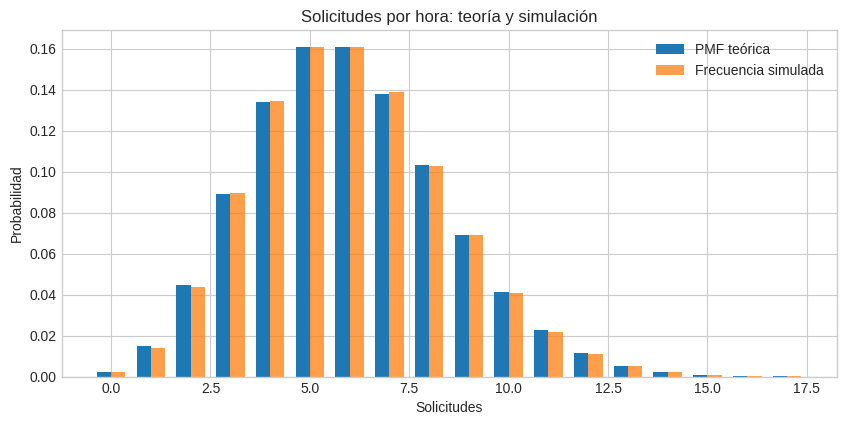

,método,P(X≥10),error estándar MC
0,Poisson exacta,0.08392,NaN
1,Monte Carlo,0.08265,0.00087


In [ ]:
lam_hora = 6
N_lab = 100_000
conteos = rng.poisson(lam_hora, size=N_lab)
xs = np.arange(0, 18)
freq = np.bincount(conteos, minlength=xs.max()+1)[:len(xs)]/N_lab
pmf = stats.poisson(lam_hora).pmf(xs)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(xs-.18, pmf, width=.36, label="PMF teórica")
ax.bar(xs+.18, freq, width=.36, alpha=.75, label="Frecuencia simulada")
ax.set(title="Solicitudes por hora: teoría y simulación", xlabel="Solicitudes", ylabel="Probabilidad")
ax.legend()
plt.show()

p_exacta = stats.poisson(lam_hora).sf(9)
p_mc = np.mean(conteos >= 10)
se_mc = np.sqrt(p_mc*(1-p_mc)/N_lab)
pd.DataFrame({
    "método": ["Poisson exacta", "Monte Carlo"],
    "P(X≥10)": [p_exacta, p_mc],
    "error estándar MC": [np.nan, se_mc]
})

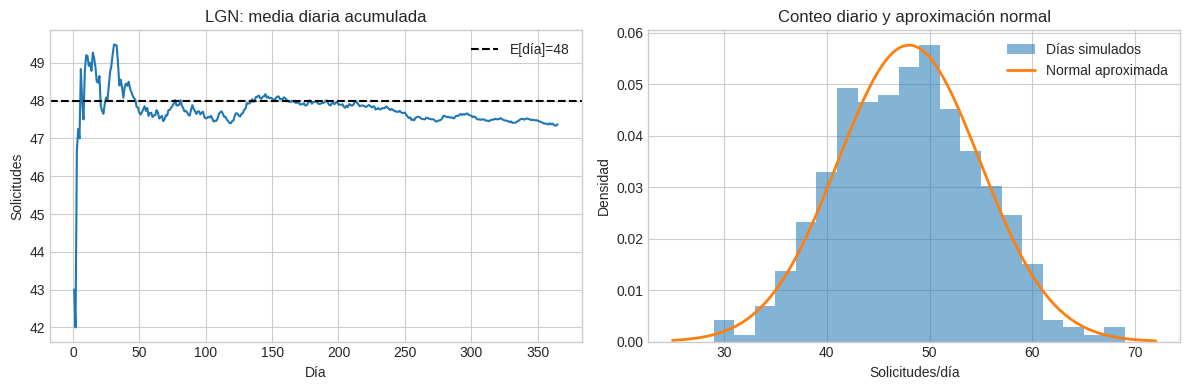

In [ ]:
dias = 365
horas = 8
solicitudes_dia = rng.poisson(lam_hora, size=(dias, horas)).sum(axis=1)
media_acum_dia = np.cumsum(solicitudes_dia)/np.arange(1, dias+1)
mu_dia = horas*lam_hora

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1,dias+1), media_acum_dia)
axes[0].axhline(mu_dia, color="black", ls="--", label=f"E[día]={mu_dia}")
axes[0].set(title="LGN: media diaria acumulada", xlabel="Día", ylabel="Solicitudes")
axes[0].legend()
axes[1].hist(solicitudes_dia, bins=np.arange(25, 73, 2), density=True, alpha=.55,
             label="Días simulados")
grid = np.linspace(25, 72, 400)
axes[1].plot(grid, stats.norm(mu_dia, np.sqrt(mu_dia)).pdf(grid), lw=2,
             label="Normal aproximada")
axes[1].set(title="Conteo diario y aproximación normal", xlabel="Solicitudes/día",
            ylabel="Densidad")
axes[1].legend()
plt.tight_layout()
plt.show()

### Interpretación del laboratorio

- La PMF y las frecuencias concuerdan, validando la simulación Poisson.
- La probabilidad Monte Carlo queda cerca del valor exacto; su error estándar
  cuantifica la incertidumbre computacional.
- La media diaria acumulada se acerca a $8(6)=48$ por la LGN.
- Un total diario es suma de ocho conteos independientes y también es
  Poisson$(48)$; por su media moderada, la aproximación normal reproduce
  razonablemente su centro. El TCL explica la forma aproximada, mientras la LGN
  explica la estabilización del promedio a través de los días.

## 14. Conclusiones

1. Una variable aleatoria conecta el espacio muestral con una ley numérica; soporte,
   PMF/PDF y CDF describen esa ley desde perspectivas complementarias.
2. Esperanza y varianza resumen centro y dispersión, pero no sustituyen la forma ni
   los supuestos de una distribución.
3. La parametrización es parte del significado del modelo. En SciPy es esencial
   distinguir tasa de escala y las convenciones de geométrica/binomial negativa.
4. Las comprobaciones de normalización y los acuerdos teórico–empíricos respaldan
   las implementaciones, sin confundir aproximación muestral con igualdad exacta.
5. La LGN explica la estabilización de promedios; el TCL, la forma de sus errores.
   Juntas sustentan la simulación de Monte Carlo y la cuantificación de su precisión.

## 15. Bibliografía

### Bibliografía principal

- Rincón, L. (2014). *Introducción a la probabilidad*. Facultad de Ciencias,
  Universidad Nacional Autónoma de México.
- Wackerly, D. D., Mendenhall III, W., y Scheaffer, R. L. (2008).
  *Mathematical Statistics with Applications* (7th ed.). Thomson Brooks/Cole.
- Ross, S. M. (2019). *A First Course in Probability* (10th ed.). Pearson.
- Mood, A. M., Graybill, F. A., y Boes, D. C. (1974).
  *Introduction to the Theory of Statistics* (3rd ed.). McGraw-Hill.



### Documentación computacional

- NumPy Developers. *Random Generator — NumPy documentation*.
- SciPy Community. *Statistical functions — scipy.stats documentation*.

> Las referencias corresponden únicamente a ediciones y materiales identificados.
> No se consignan páginas porque el desarrollo integra conceptos de varias secciones.